In [42]:
'''
This exercise is derived from coursework made by Professor John Volkens at Colorado State University
Title: ch_8_functionalProgramming
Written by: Brad Portouw
Created: 2/13/25
output: .py file
'''


'\nThis exercise is derived from coursework made by Professor John Volkens at Colorado State University\nTitle: ch_8_functionalProgramming\nWritten by: Brad Portouw\nCreated: 2/13/25\noutput: .py file\n'

In [31]:
# Setup
import math
import collections
import numpy
import numpy as np
import pandas as pd
import csv
import matplotlib.pyplot as plt
import datetime
from matplotlib import style
import seaborn as sns
import re
from datetime import date
import time
import os
pd.options.mode.chained_assignment = None

In [2]:
#This exercise has a focus on writing functions, mapping them, and cleaning/plotting data

# Writing a function named 'sort_abs()'  that takes a vector of numbers as input, calculated the absolute values of each entry, and then outputs that vector
#sorted from smallest to largest values.

In [2]:
def sort_abs(x):
    y=[]
    for i in x:
        y.append(abs(i))
    return sorted(y)


In [4]:
# While the function currently isn't perfect, it will work with proper inputs. Error alerts can we written later. 
print(sort_abs([-1, -5, 2]))

[1, 2, 5]


In [32]:
# sort_abs() sanity check
result = f"The list of numbers: {[1,0, 4, -2, -7, -9, 8]} sorted by their absolute value from lowest to highest is: {sort_abs([1,0, 4, -2, -7, -9, 8])}"
print(result)

The list of numbers: [1, 0, 4, -2, -7, -9, 8] sorted by their absolute value from lowest to highest is: [0, 1, 2, 4, 7, 8, 9]


In [6]:
# With a basic function made, the next attempt is more complicated:

# Making a fuction called 'import.w.name()' to import the "date" part of the filename (in addition to the sensor ID).
# Creating a new column variable called "date_created' with this information. Use regex: '"(?<=_)d/+(?=.csv)"'


In [33]:
# Note that the file naming convention has the date right after an underscore _ and ends with a period . so the syntax should consider this.
# The first term (?<=_) is a positive look behind assertion, where in this case it should match the expression if _ is to it's left, then perform the regex syntax to it's right
# \d+ will show all digits following the positive lookback assertion until it reaches a period . with the positive lookahead assertion (?=.csv)
#
# NOTE: Python uses backslashes \ for certain string operations, but it is also a metacharacter in regex syntax. To prevent any complications it is important to use Python's raw string notation r''
def import_w_name(pathname):
    df = pd.read_csv(pathname)
    extract = (re.findall(r'(?<=_)\d+(?=.csv)', pathname))
    string = str(extract[0])
    date = datetime.datetime.strptime(string, "%Y%m%d").date()
    # Once the dataframe and date variables are set, the dataframe needs a new column variable called a date_created 
    # df['date_created'] = date
    df.insert(0,'date_created', date)
    # Finding the sensor ID can matter for comparing different sensors and locations. This can be derived from the file name
    # The filename is typicallly in the form of SensorID_Date.csv where the sensorID is typically shown as PA123. The first bit of information before the underscore is the ID number
    # Therfore regex syntax is all alphanumeric characters until a positive lookforward for an underscore
    sensor_ID = (re.findall(r'\w+(?=_)', pathname))
    sensor_ID = str(sensor_ID[0])
    df.insert(0,'sensor_ID', sensor_ID)
    return df

    

In [34]:
# Taking a look at the imported data

path = '../../data/purpleair/PA019_20181022.csv'

df= import_w_name(path)
print(df)

    sensor_ID date_created           UTCDateTime        mac_address  \
0       PA019   2018-10-22  2018/10/22T17:52:21z  68:c6:3a:89:1d:5b   
1       PA019   2018-10-22  2018/10/22T17:53:41z  68:c6:3a:89:1d:5b   
2       PA019   2018-10-22  2018/10/22T17:55:01z  68:c6:3a:89:1d:5b   
3       PA019   2018-10-22  2018/10/22T17:56:49z  68:c6:3a:89:1d:5b   
4       PA019   2018-10-22  2018/10/22T17:58:08z  68:c6:3a:89:1d:5b   
..        ...          ...                   ...                ...   
269     PA019   2018-10-22  2018/10/22T23:54:09z  68:c6:3a:89:1d:5b   
270     PA019   2018-10-22  2018/10/22T23:55:29z  68:c6:3a:89:1d:5b   
271     PA019   2018-10-22  2018/10/22T23:56:49z  68:c6:3a:89:1d:5b   
272     PA019   2018-10-22  2018/10/22T23:58:09z  68:c6:3a:89:1d:5b   
273     PA019   2018-10-22  2018/10/22T23:59:29z  68:c6:3a:89:1d:5b   

    firmware_ver                                           hardware  \
0          2.50i  2.0+OPENLOG+15962 MB+DS3231+BME280+PMSX003A+PM...   
1    

In [35]:
# quick sanity check to see if any null values exist in the dataframe
nan_check = df.isnull().sum().any()
print(nan_check)
# This dataframe has no NaN values

False


In [10]:
'''
With the function import_w_name() the purple air csv's can be imported, and will show when the data was created and by what sensor. 
This means it would be possible to import all the csv's into a single dataframe without losing any information
Intent is to create a pipeline to read all purple air data files into a single dataframe called PA_data_merged. Then convert the character UTCDateTime into a new column of class POSIXct
Finally rename columns 'current_temp_f' and 'current_humidity' to shorter names
 ''' 

"\nWith the function import_w_name() the purple air csv's can be imported, and will show when the data was created and by what sensor. \nThis means it would be possible to import all the csv's into a single dataframe without losing any information\nIntent is to create a pipeline to read all purple air data files into a single dataframe called PA_data_merged. Then convert the character UTCDateTime into a new column of class POSIXct\nFinally rename columns 'current_temp_f' and 'current_humidity' to shorter names\n "

In [36]:
# First list all data files in the directory /purpleair (all .csv files)
dir_path = '../../data/purpleair'
file_list = []

for root, directories, files in os.walk(dir_path):
    for filename in files:
        if '.csv' in filename:
            #join the two strings in order to form full filepath for import_w_name()
            file_list.append(dir_path+'/'+filename)


print(file_list)

['../../data/purpleair/PA019_20181022.csv', '../../data/purpleair/PA019_20181023.csv', '../../data/purpleair/PA019_20181024.csv', '../../data/purpleair/PA019_20181025.csv', '../../data/purpleair/PA020_20181022.csv', '../../data/purpleair/PA020_20181023.csv', '../../data/purpleair/PA020_20181024.csv', '../../data/purpleair/PA020_20181025.csv']


In [100]:
# With a list of all data files, the map function will apply the import_w_name() iteratively to each pathname in file_list
# Note that the map function will import the data into a map object, so a conversion to a list is made to make 


# pd.concat will create a new DF every time it merges DF's; using concat in a loop will be performance intensive
# First Collect all dataframes in a list for use with pd.concat in one iteration
dataframes = []
for csv in file_list:
    dataframes.append(import_w_name(csv))

PA_data_merged = pd.concat(dataframes,ignore_index=True)

# quick sanity check to see if any null values exist in the dataframe
nan_check = PA_data_merged.isnull().sum()
# print(nan_check)

# Turns out there are NaN values in the DF, they will need to be removed
DF1 = len(PA_data_merged)
print(f'The length of the initial dataframe is {len(PA_data_merged)}')
PA_data_merged = PA_data_merged.dropna()
print(f'Some NaN values exist, {DF1 - len(PA_data_merged)} rows were removed')
# The index needs to be reset after removing values
PA_data_merged.reset_index(drop=True, inplace=True)

# Next to change the current_temp_f and current_humidity to temp_f and humidity
PA_data_merged.rename(columns={'current_temp_f': 'temp_f', 'current_humidity': 'humidity'}, inplace=True )

# Finally convert UTCDateTime to POSIXct, which is a date unit with the number of seconds since the start of 1970

The length of the initial dataframe is 9581
Some NaN values exist, 3207 rows were removed


In [101]:
# Finally convert UTCDateTime to POSIXct, which is a date unit with the number of seconds since the start of 1970
# The UTC Date Time values are strings, which should be converted to DateTime objects

print(datetime.datetime.strptime(PA_data_merged.iloc[0,2], "%Y/%m/%dT%H:%M:%Sz"))

# The index above has correct syntax for the datetime string. Saving the length of the string for reference.
str_len = len(PA_data_merged.iloc[0,2])
print(f"Correct DateTime strings should have a length of {str_len} characters")

# Checking for rows that contain UTCDateTime values that are not 20 characters long. These rows will likely need to be removed
DF_length = len(PA_data_merged)-1     # Setting length of DF
bad_dates = []
for i in range(0, DF_length):
    if len(PA_data_merged.iloc[i,2]) != str_len:
        bad_dates.append(i)
        

print(f"The index of date strings that are not 20 characters long are: {bad_dates}")
# According to the loop, two data sets are not 20 characters long: 5271 and 5356
print(f"The UTCDateTime at index 5271 is: {PA_data_merged.iloc[1131,2]}")
print(f"The UTCDateTime at index 5271 is: {PA_data_merged.iloc[5273,2]}")
print(f"The UTCDateTime at index 5356 is: {PA_data_merged.iloc[5360,2]}")
# These values can be infered by looking at their index; the time the data was collected can be found, and therefore I wouldn't recommend removing these rows. 
# Data is collected in 80 second intervals, so that will be our assumption for replacing these errors
print(f"The replacement time for the error at 1131 should be: {PA_data_merged.iloc[1130,2]} + 80 seconds or 2018/10/23T19:57:10z")
print(f"The replacement time for the error at 5356 should be: {PA_data_merged.iloc[5272,2]} + 80 seconds or 2018/10/24T17:23:55z")
print(f"The replacement time for the error at 5356 should be: {PA_data_merged.iloc[5359,2]} + 80 seconds or 2018/10/24T19:20:49z")
# Manually replacing these values:
PA_data_merged.iloc[1131,2] = "2018/10/23T19:57:10z"
PA_data_merged.iloc[5273,2] = "2018/10/24T17:23:55z"
PA_data_merged.iloc[5360,2] = "2018/10/24T19:20:49z"
print(f"The fixed date strings are {PA_data_merged.iloc[1131,2]}, {PA_data_merged.iloc[5273,2]}, and {PA_data_merged.iloc[5360,2]}")

# Hopefully all errors are removed so the string dates can be converted to datetime objects for easier use
for i in range(0, DF_length):
    # First convert each UTCDateTime string into a datetime object
    PA_data_merged.iloc[i, 2] = datetime.datetime.strptime(PA_data_merged.iloc[i,2], "%Y/%m/%dT%H:%M:%Sz")

# ALl elements were 20 characters long and matched the datetime syntax, so everything is good!
PA_data_merged.iloc[0,2].timestamp()
print(PA_data_merged.iloc[0,2].timestamp())
# Having the .timestamp method used on PA_data_merged.iloc[i,2] was throwing an error, saying that the output was a float when it was actually a datetime
# Trying again here to see if a separate loop will work better

# PA_data_merged.iloc[0,2] = PA_data_merged.iloc[0,2].timestamp()
# print(PA_data_merged.iloc[0,2])

# The method above works, but when it is used in a loop, an error occurs:
for j in range(0,DF_length):
    PA_data_merged.iloc[j,2] = PA_data_merged.iloc[j,2].timestamp()

# With a dataframe with epoch time values, next is to update some column names:

PA_data_merged.rename(columns={'UTCDateTime': 'POSIXct'}, inplace=True)
# PA_data_merged['UTCDateTime'] = PA_data_merged['UTCDateTime'].apply(lambda x: x.timestamp())
PA_data_merged.head()
# for i in range(0, DF_length):
#     #Convert UTC DateTime to an epoch value in seconds
#     PA_data_merged.iloc[i,2] = PA_data_merged.iloc[0,2].timestamp()

# # # First Rename colun from 'UTCDateTime' to 'POSIXct'
# PA_data_merged.rename(columns={'UTCDateTime': 'POSIXct'})



2018-10-22 17:52:21
Correct DateTime strings should have a length of 20 characters
The index of date strings that are not 20 characters long are: [1131, 5273, 5360]
The UTCDateTime at index 5271 is: 3724 31504ÿÿÿÿÿÿÿÿÿÿÿè
The UTCDateTime at index 5271 is: 3723 31504 2018/10ÿÿÿÿÿÿÿÿÿÿÿè
The UTCDateTime at index 5356 is: 82 31784 2018/10/24T19:19:29z:Found BME280 seÿÿÿÿÿÿÿÿÿÿÿè
The replacement time for the error at 1131 should be: 2018/10/23T19:55:50z + 80 seconds or 2018/10/23T19:57:10z
The replacement time for the error at 5356 should be: 2018/10/24T17:22:35z + 80 seconds or 2018/10/24T17:23:55z
The replacement time for the error at 5356 should be: 2018/10/24T19:19:29z + 80 seconds or 2018/10/24T19:20:49z
The fixed date strings are 2018/10/23T19:57:10z, 2018/10/24T17:23:55z, and 2018/10/24T19:20:49z
1540252341.0


,sensor_ID,date_created,POSIXct,mac_address,firmware_ver,hardware,temp_f,humidity,current_dewpoint_f,pressure,...,pm10_0_atm_b,pm1_0_cf_1_b,pm2_5_cf_1_b,pm10_0_cf_1_b,p_0_3_um_b,p_0_5_um_b,p_1_0_um_b,p_2_5_um_b,p_5_0_um_b,p_10_0_um_b
0,PA019,2018-10-22,1540252341.0,68:c6:3a:89:1d:5b,2.50i,2.0+OPENLOG+15962 MB+DS3231+BME280+PMSX003A+PM...,90.0,12.0,30.59,851.66,...,3.05,2.40,2.74,3.05,533.43,164.31,16.19,0.57,0.38,0.29
1,PA019,2018-10-22,1540252421.0,68:c6:3a:89:1d:5b,2.50i,2.0+OPENLOG+15962 MB+DS3231+BME280+PMSX003A+PM...,86.0,13.0,29.44,851.68,...,3.24,2.58,3.24,3.24,567.32,174.92,15.97,0.42,0.38,0.29
2,PA019,2018-10-22,1540252501.0,68:c6:3a:89:1d:5b,2.50i,2.0+OPENLOG+15962 MB+DS3231+BME280+PMSX003A+PM...,87.0,13.0,30.22,851.56,...,2.73,1.95,2.54,2.73,464.51,143.46,14.22,0.59,0.27,0.27
3,PA019,2018-10-22,1540252609.0,68:c6:3a:89:1d:5b,2.50i,2.0+OPENLOG+15962 MB+DS3231+BME280+PMSX003A+PM...,87.0,13.0,30.22,851.59,...,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
4,PA019,2018-10-22,1540252688.0,68:c6:3a:89:1d:5b,2.50i,2.0+OPENLOG+15962 MB+DS3231+BME280+PMSX003A+PM...,87.0,13.0,30.22,851.54,...,2.19,1.59,2.19,2.19,442.62,138.32,17.32,0.00,0.00,0.00


In [108]:
# Now that the data has been imported properly and sorted by sensor and date, creating a series of Exploratory Data Analysis plots (cdf, boxplot, histogram, time series) from the 'pm2_5_atm' can 
#give information about fine particulate matter in micrograms per cubic meter

# First it would be benefical to group the data by it's corresponding sensor

PA_sensors = PA_data_merged.groupby('sensor_ID')
PA_sensors.head()

,sensor_ID,date_created,POSIXct,mac_address,firmware_ver,hardware,temp_f,humidity,current_dewpoint_f,pressure,...,pm10_0_atm_b,pm1_0_cf_1_b,pm2_5_cf_1_b,pm10_0_cf_1_b,p_0_3_um_b,p_0_5_um_b,p_1_0_um_b,p_2_5_um_b,p_5_0_um_b,p_10_0_um_b
0,PA019,2018-10-22,1540252341.0,68:c6:3a:89:1d:5b,2.50i,2.0+OPENLOG+15962 MB+DS3231+BME280+PMSX003A+PM...,90.0,12.0,30.59,851.66,...,3.05,2.40,2.74,3.05,533.43,164.31,16.19,0.57,0.38,0.29
1,PA019,2018-10-22,1540252421.0,68:c6:3a:89:1d:5b,2.50i,2.0+OPENLOG+15962 MB+DS3231+BME280+PMSX003A+PM...,86.0,13.0,29.44,851.68,...,3.24,2.58,3.24,3.24,567.32,174.92,15.97,0.42,0.38,0.29
2,PA019,2018-10-22,1540252501.0,68:c6:3a:89:1d:5b,2.50i,2.0+OPENLOG+15962 MB+DS3231+BME280+PMSX003A+PM...,87.0,13.0,30.22,851.56,...,2.73,1.95,2.54,2.73,464.51,143.46,14.22,0.59,0.27,0.27
3,PA019,2018-10-22,1540252609.0,68:c6:3a:89:1d:5b,2.50i,2.0+OPENLOG+15962 MB+DS3231+BME280+PMSX003A+PM...,87.0,13.0,30.22,851.59,...,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
4,PA019,2018-10-22,1540252688.0,68:c6:3a:89:1d:5b,2.50i,2.0+OPENLOG+15962 MB+DS3231+BME280+PMSX003A+PM...,87.0,13.0,30.22,851.54,...,2.19,1.59,2.19,2.19,442.62,138.32,17.32,0.00,0.00,0.00
3186,PA020,2018-10-22,1540252535.0,84:f3:eb:91:44:3a,2.50i,2.0+OPENLOG+15962 MB+DS3231+BME280+PMSX003A+PM...,96.0,9.0,28.10,850.90,...,2.40,1.83,2.40,2.40,510.14,137.00,15.24,0.21,0.28,0.48
3187,PA020,2018-10-22,1540252639.0,84:f3:eb:91:44:3a,2.50i,2.0+OPENLOG+15962 MB+DS3231+BME280+PMSX003A+PM...,93.0,10.0,28.41,850.92,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3188,PA020,2018-10-22,1540252713.0,84:f3:eb:91:44:3a,2.50i,2.0+OPENLOG+15962 MB+DS3231+BME280+PMSX003A+PM...,90.0,10.0,26.14,850.97,...,2.09,1.79,2.09,2.09,542.91,143.30,11.00,0.27,0.00,0.00
3189,PA020,2018-10-22,1540252793.0,84:f3:eb:91:44:3a,2.50i,2.0+OPENLOG+15962 MB+DS3231+BME280+PMSX003A+PM...,91.0,11.0,29.22,850.93,...,3.44,1.92,2.75,3.44,515.50,141.00,18.47,1.92,0.92,0.44
3190,PA020,2018-10-22,1540252873.0,84:f3:eb:91:44:3a,2.50i,2.0+OPENLOG+15962 MB+DS3231+BME280+PMSX003A+PM...,91.0,11.0,29.22,850.93,...,1.94,1.49,1.94,1.94,467.23,130.03,12.23,0.43,0.92,0.44


In [111]:
PA_data_merged.columns

Index(['sensor_ID', 'date_created', 'POSIXct', 'mac_address', 'firmware_ver',
       'hardware', 'temp_f', 'humidity', 'current_dewpoint_f', 'pressure',
       'adc', 'mem', 'rssi', 'uptime', 'pm1_0_atm', 'pm2_5_atm', 'pm10_0_atm',
       'pm1_0_cf_1', 'pm2_5_cf_1', 'pm10_0_cf_1', 'p_0_3_um', 'p_0_5_um',
       'p_1_0_um', 'p_2_5_um', 'p_5_0_um', 'p_10_0_um', 'pm1_0_atm_b',
       'pm2_5_atm_b', 'pm10_0_atm_b', 'pm1_0_cf_1_b', 'pm2_5_cf_1_b',
       'pm10_0_cf_1_b', 'p_0_3_um_b', 'p_0_5_um_b', 'p_1_0_um_b', 'p_2_5_um_b',
       'p_5_0_um_b', 'p_10_0_um_b'],
      dtype='object')

In [144]:
# For the upcoming plots, many of the columns aren't used, so a separate dataframe is created with pm2_5_atm includedd
# To build a cumulative distribution plot. First the 'pm2_5_atm' values should be sorted


PA_cumulative = PA_data_merged[['sensor_ID','date_created', 'POSIXct', 'temp_f', 'humidity','pressure','pm2_5_atm']]
# PA_cumulative = PA_cumulative.sort_values(['sensor_ID', 'pm2_5_atm']).groupby('sensor_ID')
# PA_cumulative.head()

# In this case I separated each set of data for sensor 19 and 20 into separate dataframes.
cumulative_PA19 = PA_cumulative.loc[PA_data_merged['sensor_ID'] == 'PA019']
cumulative_PA19.sort_values('pm2_5_atm', inplace=True)
# Adding a cumulative probabality as a y value in the plot
cfd_sorted19 = np.arange(1, len(cumulative_PA19)+1)/len(cumulative_PA19)

# Sensor 20 pm2_5_atm values sorted in ascending order:
cumulative_PA20 = PA_cumulative.loc[PA_data_merged['sensor_ID'] == 'PA020']
cumulative_PA20.sort_values('pm2_5_atm', inplace=True)
print(cumulative_PA20)

# Making the cumulative fraction for the plot. These are essentially the y values in the plot for 
cfd_sorted20 = np.arange(1, len(cumulative_PA20)+1)/len(cumulative_PA20)
print(cfd_sorted20)


     sensor_ID date_created       POSIXct  temp_f  humidity  pressure  \
3332     PA020   2018-10-22  1540264329.0    90.0      10.0    849.52   
6179     PA020   2018-10-25  1540496690.0    55.0      36.0    846.63   
6073     PA020   2018-10-25  1540488172.0    56.0      31.0    845.67   
6366     PA020   2018-10-25  1540511776.0    80.0      11.0    846.29   
6363     PA020   2018-10-25  1540511536.0    80.0      11.0    846.35   
...        ...          ...           ...     ...       ...       ...   
5741     PA020   2018-10-25  1540461180.0    59.0      42.0    845.26   
5709     PA020   2018-10-25  1540458602.0    62.0      41.0    845.25   
5708     PA020   2018-10-25  1540458522.0    62.0      41.0    845.21   
5736     PA020   2018-10-25  1540460762.0    60.0      41.0    845.37   
5733     PA020   2018-10-25  1540460522.0    60.0      41.0    845.32   

      pm2_5_atm  
3332       0.00  
6179       0.00  
6073       0.00  
6366       0.50  
6363       0.55  
...         ...

([<matplotlib.axis.YTick at 0x1dd2c98e5d0>,
 [Text(0, 0.0, '0.0'),
  Text(0, 0.1, '0.1'),
  Text(0, 0.2, '0.2'),
  Text(0, 0.30000000000000004, '0.3'),
  Text(0, 0.4, '0.4'),
  Text(0, 0.5, '0.5'),
  Text(0, 0.6000000000000001, '0.6'),
  Text(0, 0.7000000000000001, '0.7'),
  Text(0, 0.8, '0.8'),
  Text(0, 0.9, '0.9'),
  Text(0, 1.0, '1.0')])

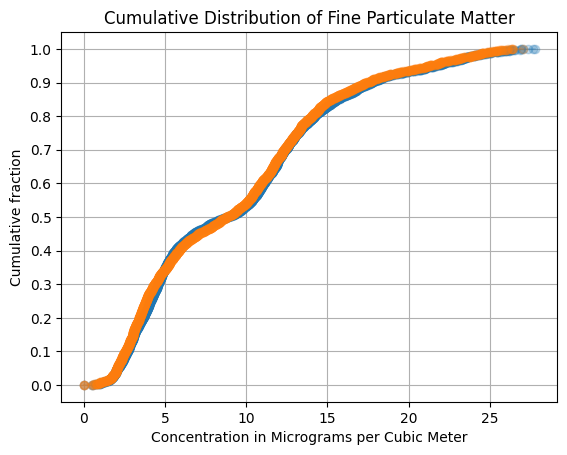

In [162]:
plt.plot(cumulative_PA19['pm2_5_atm'], cfd_sorted19, marker='o', alpha=0.25)
plt.plot(cumulative_PA20['pm2_5_atm'], cfd_sorted20, marker='o', alpha=0.25)
plt.title("Cumulative Distribution of Fine Particulate Matter")
plt.grid(True)
plt.xlabel("Concentration in Micrograms per Cubic Meter")
plt.ylabel("Cumulative fraction")
plt.yticks(np.linspace(0.0, 1.0, 11))

#The cumulative distibution plot below suggests that each sensor had roughly the same results. Half of the results fell between a smaller grouping between 0 and 10 micrograms per m^3, while concentrations higher than 10 micrograms saw more varience.

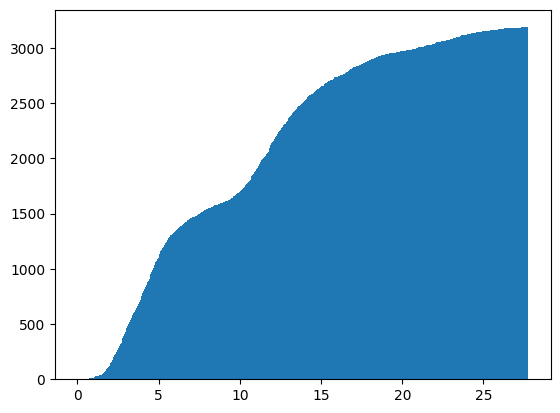

In [140]:
plt.hist(cumulative_PA19['pm2_5_atm'],
        bins=500,
        )

In [117]:
PA_cumulative = PA_data_merged.sort_values(['sensor_ID', 'pm2_5_atm'], ascending=False).groupby('sensor_ID')
PA_cumulative['pm2_5_atm'])